In [7]:
# !pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import nltk
from nltk.corpus import stopwords 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from wordcloud import WordCloud




In [9]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRATHAM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
data = pd.read_csv('twitter_training.csv' , header=None, names=['Id', 'sentiments' , 'text'  ] )
print(data.head())
print(data.shape)

               Id sentiments  \
2401  Borderlands   Positive   
2401  Borderlands   Positive   
2401  Borderlands   Positive   
2401  Borderlands   Positive   
2401  Borderlands   Positive   

                                                   text  
2401  im getting on borderlands and i will murder yo...  
2401  I am coming to the borders and I will kill you...  
2401  im getting on borderlands and i will kill you ...  
2401  im coming on borderlands and i will murder you...  
2401  im getting on borderlands 2 and i will murder ...  
(74682, 3)


In [23]:
data = data[['text' , 'sentiments']]

data.dropna()
# 

,text,sentiments
2401,im getting on borderlands and i will murder yo...,Positive
2401,I am coming to the borders and I will kill you...,Positive
2401,im getting on borderlands and i will kill you ...,Positive
2401,im coming on borderlands and i will murder you...,Positive
2401,im getting on borderlands 2 and i will murder ...,Positive
...,...,...
9200,Just realized that the Windows partition of my...,Positive
9200,Just realized that my Mac window partition is ...,Positive
9200,Just realized the windows partition of my Mac ...,Positive
9200,Just realized between the windows partition of...,Positive


In [30]:
data = data.dropna(subset=['text'])

In [31]:
import re

def clean_text(text):

    if isinstance(text, str):

        text = text.lower()

        text = re.sub(r'[^a-zA-Z]', ' ', text)

        words = text.split()

        return " ".join(words)

    else:
        return ""

In [32]:
data['clean_text'] = data['text'].apply(clean_text)


print(data.head())

                                                   text sentiments  \
2401  im getting on borderlands and i will murder yo...   Positive   
2401  I am coming to the borders and I will kill you...   Positive   
2401  im getting on borderlands and i will kill you ...   Positive   
2401  im coming on borderlands and i will murder you...   Positive   
2401  im getting on borderlands 2 and i will murder ...   Positive   

                                             clean_text  
2401  im getting on borderlands and i will murder yo...  
2401  i am coming to the borders and i will kill you...  
2401  im getting on borderlands and i will kill you all  
2401  im coming on borderlands and i will murder you...  
2401  im getting on borderlands and i will murder yo...  


C:\Users\PRATHAM\AppData\Local\Temp\ipykernel_9944\1340790662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['clean_text'] = data['text'].apply(clean_text)


In [34]:
vectorizer = TfidfVectorizer(max_features=5000)

x = vectorizer.fit_transform(data['clean_text'])
y = data['sentiments']


In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


In [36]:
model = MultinomialNB()
model.fit(x_train , y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(x_test)


['Irrelevant' 'Irrelevant' 'Neutral' ... 'Negative' 'Positive' 'Positive']


In [39]:
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy: ", accuracy)
print("Classification Report: \n", classification_report(y_test , y_pred))


Accuracy:  0.6413513513513514
Classification Report: 
               precision    recall  f1-score   support

  Irrelevant       0.76      0.32      0.45      2696
    Negative       0.62      0.82      0.71      4380
     Neutral       0.69      0.53      0.60      3605
    Positive       0.61      0.76      0.68      4119

    accuracy                           0.64     14800
   macro avg       0.67      0.61      0.61     14800
weighted avg       0.66      0.64      0.63     14800



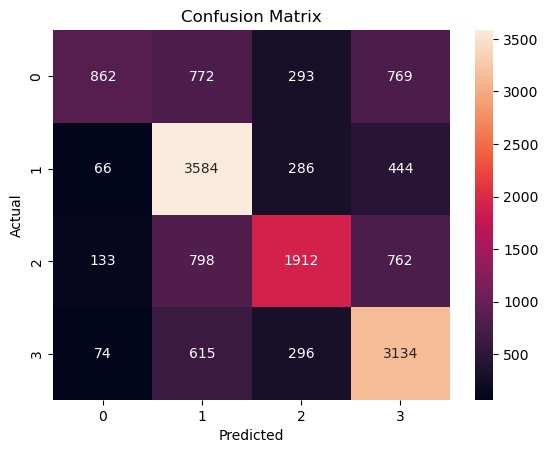

In [40]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

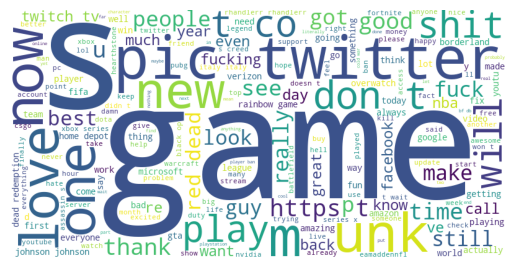

In [42]:
text = " ".join(data['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis('off')

plt.show()

In [47]:
sentence = ["I love this product, it's amazing"]

sentence = [clean_text(sentence[0])]

vector = vectorizer.transform(sentence)

prediction = model.predict(vector)

print("Sentiment:", prediction[0])

Sentiment: Positive
